In [41]:

# Applied AI & ML Essentials - Capstone Project
# Part 1 - Data Acquisition, Cleaning and Exploratory Analysis
# Dataset : UCI Bike Sharing Dataset (day.csv)


In [42]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Shows graphs inside the notebook itself,instead of showing it in a new window
%matplotlib inline

In [43]:
df = pd.read_csv("day.csv")

In [44]:
# Read the dataset
df = pd.read_csv("day.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [45]:
#datset information
print("First Five Rows")
df.head()
print("Data Types")
print(df.dtypes)
print("Shape of Dataset")
print(df.shape)
print("Dataset Information")
df.info()


First Five Rows
Data Types
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object
Shape of Dataset
(731, 16)
Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9  

In [46]:
total_missing = df.isnull().sum()
missing_percent = (total_missing / len(df)) * 100
null_table = pd.DataFrame({
    "Missing Values": total_missing,
    "Missing Percentage": missing_percent
})
print(null_table)

            Missing Values  Missing Percentage
instant                  0                 0.0
dteday                   0                 0.0
season                   0                 0.0
yr                       0                 0.0
mnth                     0                 0.0
holiday                  0                 0.0
weekday                  0                 0.0
workingday               0                 0.0
weathersit               0                 0.0
temp                     0                 0.0
atemp                    0                 0.0
hum                      0                 0.0
windspeed                0                 0.0
casual                   0                 0.0
registered               0                 0.0
cnt                      0                 0.0


In [47]:
null_calculation= null_table[null_table["Missing Percentage"] > 20]
print("Columns having more than 20% missing values")
print(null_calculation)

Columns having more than 20% missing values
Empty DataFrame
Columns: [Missing Values, Missing Percentage]
Index: []


In [48]:
#replacing missing values with median
#median will not be affected much by outliers,so filling with median
for column in df.columns:
    if df[column].dtype != "object":            #skips text colums
        if df[column].isnull().mean() < 0.20:
            median = df[column].median()
            df[column] = df[column].fillna(median)
print("Missing values filled.")

Missing values filled.


In [49]:
print(df.isnull().sum())
duplicates = df.duplicated().sum()
print("Duplicate Rows")
print(duplicates)
#this will print duplicate rows
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)
removed = rows_before - rows_after
#comparison of before and after duplicates removal
print("Rows Removed :", removed)
print("New Shape :", df.shape)

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Duplicate Rows
0
Rows Removed : 0
New Shape : (731, 16)


In [50]:
#missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
new_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent
})
print(new_table)

            Missing Values  Missing Percentage
instant                  0                 0.0
dteday                   0                 0.0
season                   0                 0.0
yr                       0                 0.0
mnth                     0                 0.0
holiday                  0                 0.0
weekday                  0                 0.0
workingday               0                 0.0
weathersit               0                 0.0
temp                     0                 0.0
atemp                    0                 0.0
hum                      0                 0.0
windspeed                0                 0.0
casual                   0                 0.0
registered               0                 0.0
cnt                      0                 0.0


In [51]:
#shows the memory used before conversion
memory_before = df.memory_usage(deep=True).sum()
print("Memory Usage Before Conversion")
print(memory_before)

Memory Usage Before Conversion
130981


In [52]:
#date type conversion from string
df["dteday"] = pd.to_datetime(df["dteday"])
#category labelling
category_columns = [
    "season",
    "yr",
    "mnth",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]
for column in category_columns:
    df[column] = df[column].astype("category")

In [53]:
memory_after = df.memory_usage(deep=True).sum()
print("Memory Usage After Conversion")
print(memory_after)
print("Memory Saved")
print(memory_before - memory_after)

Memory Usage After Conversion
59341
Memory Saved
71640


In [54]:
print(df.describe())

          instant               dteday        temp       atemp         hum  \
count  731.000000                  731  731.000000  731.000000  731.000000   
mean   366.000000  2012-01-01 00:00:00    0.495385    0.474354    0.627894   
min      1.000000  2011-01-01 00:00:00    0.059130    0.079070    0.000000   
25%    183.500000  2011-07-02 12:00:00    0.337083    0.337842    0.520000   
50%    366.000000  2012-01-01 00:00:00    0.498333    0.486733    0.626667   
75%    548.500000  2012-07-01 12:00:00    0.655417    0.608602    0.730209   
max    731.000000  2012-12-31 00:00:00    0.861667    0.840896    0.972500   
std    211.165812                  NaN    0.183051    0.162961    0.142429   

        windspeed       casual   registered          cnt  
count  731.000000   731.000000   731.000000   731.000000  
mean     0.190486   848.176471  3656.172367  4504.348837  
min      0.022392     2.000000    20.000000    22.000000  
25%      0.134950   315.500000  2497.000000  3152.000000  
50

In [55]:
#calculates skew
numeric_columns = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "casual",
    "registered",
    "cnt"
]
print("Skewness of Numeric Columns")
for column in numeric_columns:
    print(column, ":", df[column].skew())

Skewness of Numeric Columns
temp : -0.054520964760408276
atemp : -0.13108804205446
hum : -0.06978343399095213
windspeed : 0.6773454211095378
casual : 1.2664540319434734
registered : 0.04365877988903687
cnt : -0.04735278011900183


In [56]:
# Find skewness for numeric columns again
skewed_vals = {}
for col in numeric_columns:
    skewed_vals[col] = df[col].skew()
# Convert to DataFrame
skew_df = pd.DataFrame(list(skewed_vals.items()), columns=["Column", "Skewness"])
print(skew_df)
# Most skewed column
most_skewed = skew_df.loc[skew_df["Skewness"].abs().idxmax(), "Column"]
print("Most Skewed Column:", most_skewed)

       Column  Skewness
0        temp -0.054521
1       atemp -0.131088
2         hum -0.069783
3   windspeed  0.677345
4      casual  1.266454
5  registered  0.043659
6         cnt -0.047353
Most Skewed Column: casual


In [57]:
print("Mean and Median Comparison")
for col in skew_df["Column"]:
    print("\nColumn:", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())

Mean and Median Comparison

Column: temp
Mean: 0.495384788508892
Median: 0.498333

Column: atemp
Mean: 0.47435398864569084
Median: 0.486733

Column: hum
Mean: 0.6278940629274967
Median: 0.626667

Column: windspeed
Mean: 0.190486211627907
Median: 0.180975

Column: casual
Mean: 848.1764705882352
Median: 713.0

Column: registered
Mean: 3656.172366621067
Median: 3662.0

Column: cnt
Mean: 4504.3488372093025
Median: 4548.0


In [58]:
#feature column outlier
col = "temp"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier = df[(df[col] < lower) | (df[col] > upper)]
print("Outliers in temp:", len(outlier))

Outliers in temp: 0


In [59]:
#target column outlier
col = "cnt"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower) | (df[col] > upper)]
print("Outliers in cnt:", len(outliers))

Outliers in cnt: 0


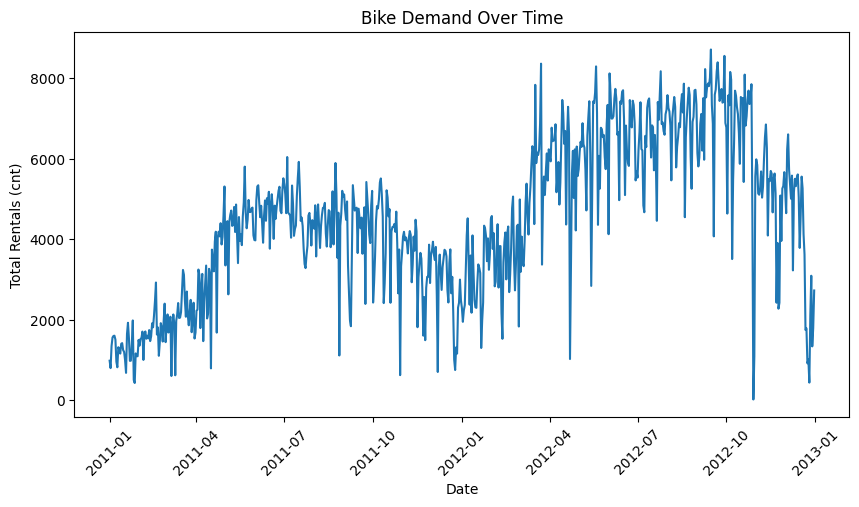

In [60]:
#lineplot
plt.figure(figsize=(10,5))
plt.plot(df["dteday"], df["cnt"])
plt.title("Bike Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Rentals (cnt)")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_12460/1033652207.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("season")["cnt"].mean().plot(kind="bar")


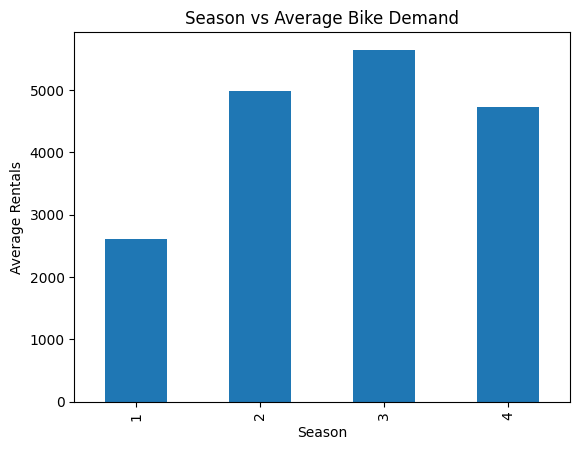

In [61]:
#bar plot
df.groupby("season")["cnt"].mean().plot(kind="bar")
plt.title("Season vs Average Bike Demand")
plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.show()

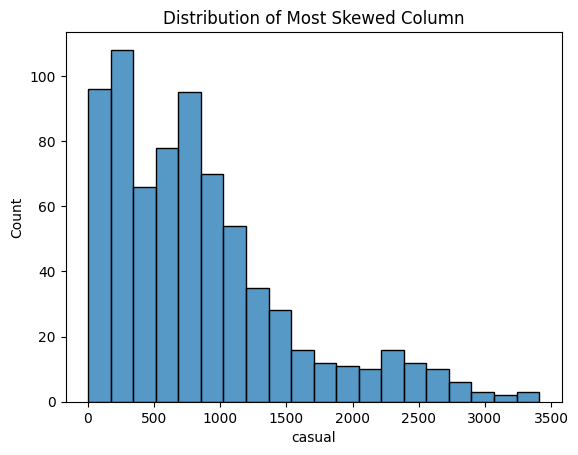

In [62]:
#histogram
sns.histplot(df[most_skewed], bins=20)
plt.title("Distribution of Most Skewed Column")
plt.show()

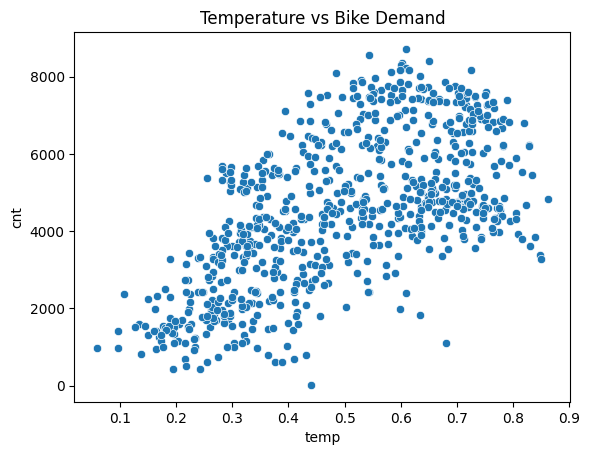

In [63]:
#scatterplot
sns.scatterplot(x="temp", y="cnt", data=df)
plt.title("Temperature vs Bike Demand")
plt.show()

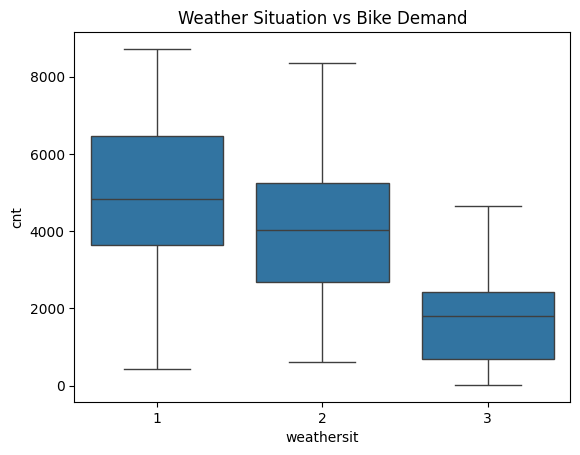

In [64]:
#boxplot
sns.boxplot(x="weathersit", y="cnt", data=df)
plt.title("Weather Situation vs Bike Demand")
plt.show()

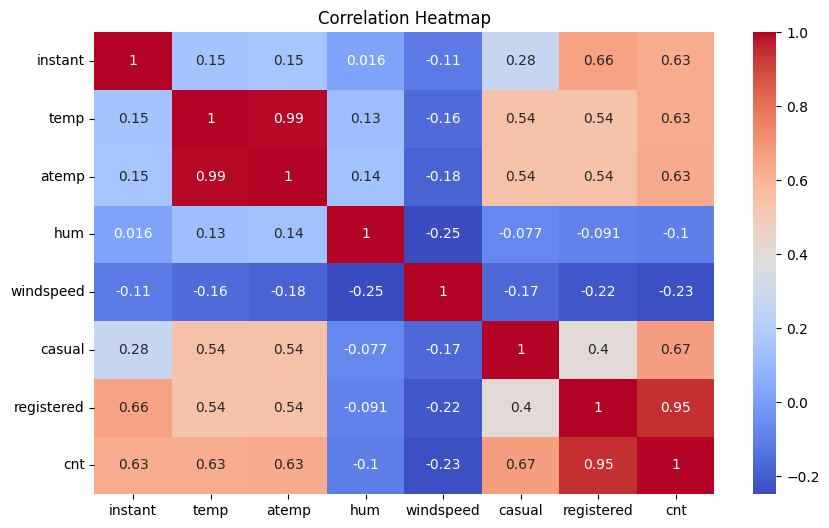

In [65]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [66]:
pearson = df.corr(numeric_only=True)
print(pearson)

             instant      temp     atemp       hum  windspeed    casual  \
instant     1.000000  0.150580  0.152638  0.016375  -0.112620  0.275255   
temp        0.150580  1.000000  0.991702  0.126963  -0.157944  0.543285   
atemp       0.152638  0.991702  1.000000  0.139988  -0.183643  0.543864   
hum         0.016375  0.126963  0.139988  1.000000  -0.248489 -0.077008   
windspeed  -0.112620 -0.157944 -0.183643 -0.248489   1.000000 -0.167613   
casual      0.275255  0.543285  0.543864 -0.077008  -0.167613  1.000000   
registered  0.659623  0.540012  0.544192 -0.091089  -0.217449  0.395282   
cnt         0.628830  0.627494  0.631066 -0.100659  -0.234545  0.672804   

            registered       cnt  
instant       0.659623  0.628830  
temp          0.540012  0.627494  
atemp         0.544192  0.631066  
hum          -0.091089 -0.100659  
windspeed    -0.217449 -0.234545  
casual        0.395282  0.672804  
registered    1.000000  0.945517  
cnt           0.945517  1.000000  


In [67]:
spearman = df.corr(method="spearman", numeric_only=True)
print(spearman)

             instant      temp     atemp       hum  windspeed    casual  \
instant     1.000000  0.142260  0.141877  0.010187  -0.129932  0.312920   
temp        0.142260  1.000000  0.992554  0.129903  -0.147153  0.667427   
atemp       0.141877  0.992554  1.000000  0.139648  -0.168987  0.667679   
hum         0.010187  0.129903  0.139648  1.000000  -0.239006 -0.070781   
windspeed  -0.129932 -0.147153 -0.168987 -0.239006   1.000000 -0.180319   
casual      0.312920  0.667427  0.667679 -0.070781  -0.180319  1.000000   
registered  0.663618  0.531167  0.531883 -0.093222  -0.202979  0.523609   
cnt         0.630191  0.622034  0.622782 -0.098126  -0.217197  0.753501   

            registered       cnt  
instant       0.663618  0.630191  
temp          0.531167  0.622034  
atemp         0.531883  0.622782  
hum          -0.093222 -0.098126  
windspeed    -0.202979 -0.217197  
casual        0.523609  0.753501  
registered    1.000000  0.940319  
cnt           0.940319  1.000000  


In [68]:
diff = abs(spearman - pearson)
print("Difference Matrix")
print(diff)

Difference Matrix
             instant      temp     atemp       hum  windspeed    casual  \
instant     0.000000  0.008321  0.010762  0.006188   0.017313  0.037665   
temp        0.008321  0.000000  0.000853  0.002940   0.010791  0.124142   
atemp       0.010762  0.000853  0.000000  0.000341   0.014656  0.123816   
hum         0.006188  0.002940  0.000341  0.000000   0.009483  0.006226   
windspeed   0.017313  0.010791  0.014656  0.009483   0.000000  0.012705   
casual      0.037665  0.124142  0.123816  0.006226   0.012705  0.000000   
registered  0.003995  0.008845  0.012309  0.002134   0.014470  0.128326   
cnt         0.001361  0.005460  0.008284  0.002533   0.017348  0.080696   

            registered       cnt  
instant       0.003995  0.001361  
temp          0.008845  0.005460  
atemp         0.012309  0.008284  
hum           0.002134  0.002533  
windspeed     0.014470  0.017348  
casual        0.128326  0.080696  
registered    0.000000  0.005198  
cnt           0.005198  0.

In [69]:
diff = (spearman - pearson).abs()
pairs = []
cols = diff.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], diff.iloc[i, j]))
pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
print("Top 3 Pearson vs Spearman Differences")
for col1, col2, value in pairs[:3]:
    print(f"{col1} - {col2}: {value:.4f}")

Top 3 Pearson vs Spearman Differences
casual - registered: 0.1283
temp - casual: 0.1241
atemp - casual: 0.1238


In [70]:
result = df.groupby("season")["cnt"].agg(["mean", "std", "count"])
print(result)

               mean          std  count
season                                 
1       2604.132597  1399.942119    181
2       4992.331522  1695.977235    184
3       5644.303191  1459.800381    188
4       4728.162921  1699.615261    178


/tmp/ipykernel_12460/3586936995.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby("season")["cnt"].agg(["mean", "std", "count"])


In [71]:
df.to_csv("cleaned_data.csv", index=False)
print("cleaned_data.csv saved successfully")

cleaned_data.csv saved successfully


In [72]:
highest_mean = result["mean"].idxmax()
lowest_mean = result["mean"].idxmin()
mean_ratio = result.loc[highest_mean, "mean"] / result.loc[lowest_mean, "mean"]
print("Highest Mean Group:", highest_mean)
print("Lowest Mean Group:", lowest_mean)
print("Mean Ratio:", round(mean_ratio, 2))

Highest Mean Group: 3
Lowest Mean Group: 1
Mean Ratio: 2.17
